<a href="https://colab.research.google.com/github/rotoncsedu/Computer-Vision/blob/main/Visualization_of_layers_output.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from tensorflow import keras
from tensorflow.keras import layers
inputs = keras.Input(shape = (128,128,3))
x= layers.Rescaling(1./255)(inputs)
x= layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x= layers.MaxPooling2D(pool_size=2)(x)
x= layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x= layers.MaxPooling2D(pool_size=2)(x)
x= layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x= layers.MaxPooling2D(pool_size=2)(x)
x= layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x= layers.MaxPooling2D(pool_size=2)(x)
x= layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x= layers.Flatten()(x)
outputs= layers.Dense(1, activation="sigmoid")(x)
model= keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 982,593 (3.75 MB)

 Trainable params: 982,593 (3.75 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
import numpy as np
from tensorflow import keras # Added this import
img_path = keras.utils.get_file("cat.jpg", "https://img-datasets.s3.amazonaws.com/cat.jpg")

def get_img_array(img_path, size):
    img = keras.utils.load_img(img_path, target_size=size)
    array = keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array

img_tensor = get_img_array(img_path, size = (128,128))

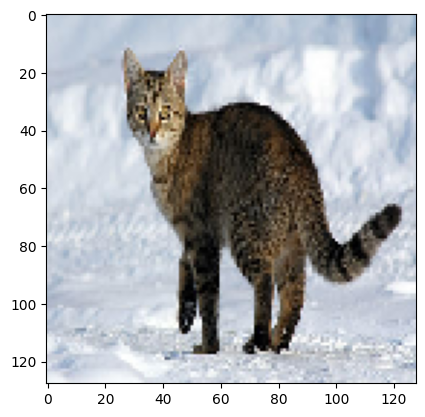

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

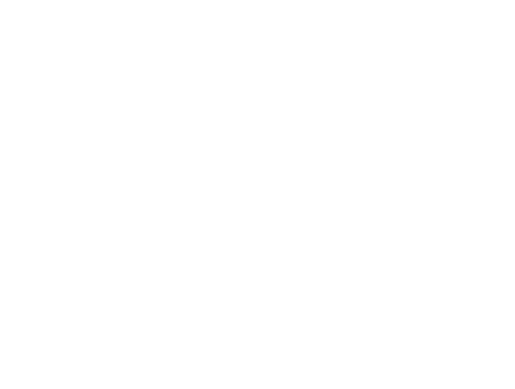

In [15]:
import matplotlib.pyplot as plt
plt.imshow(img_tensor[0].astype("uint8"))
plt.show()
plt.axis("off")

In [17]:
from tensorflow import keras
from tensorflow.keras import layers

layers_output = []
layers_name = []

for layer in model.layers:
    if isinstance(layer, (layers.Conv2D, layers.MaxPooling2D)):
        layers_output.append(layer.output)
        layers_name.append(layer.name)

activation_model = keras.Model(inputs=model.input, outputs=layers_output)
activation_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 978,496 (3.73 MB)

 Trainable params: 978,496 (3.73 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
activation = activation_model.predict(img_tensor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step


In [19]:
first_layer_activation = activation[0]
print(first_layer_activation.shape)

(1, 126, 126, 32)


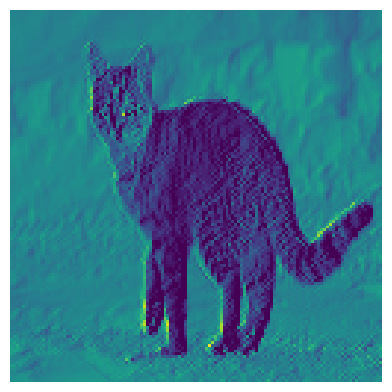

In [22]:
import matplotlib.pyplot as plt
plt.matshow(first_layer_activation[0, :, :, 2], cmap="viridis")
plt.axis("off")
plt.show()
#

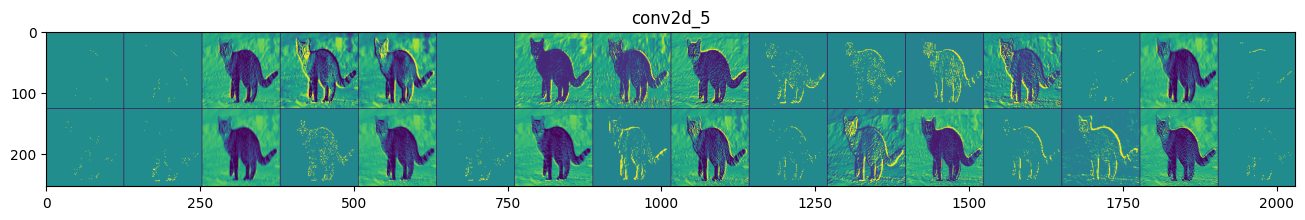

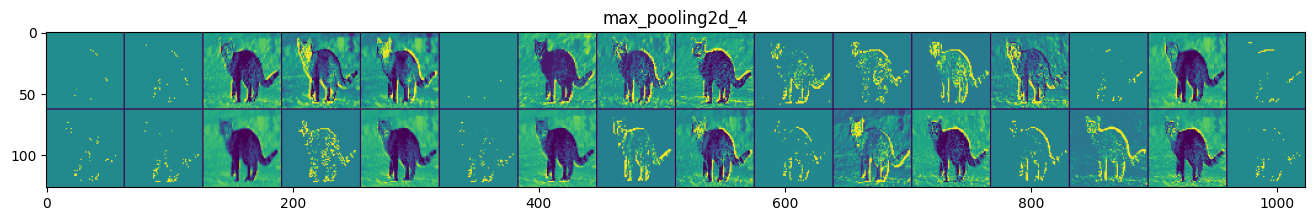

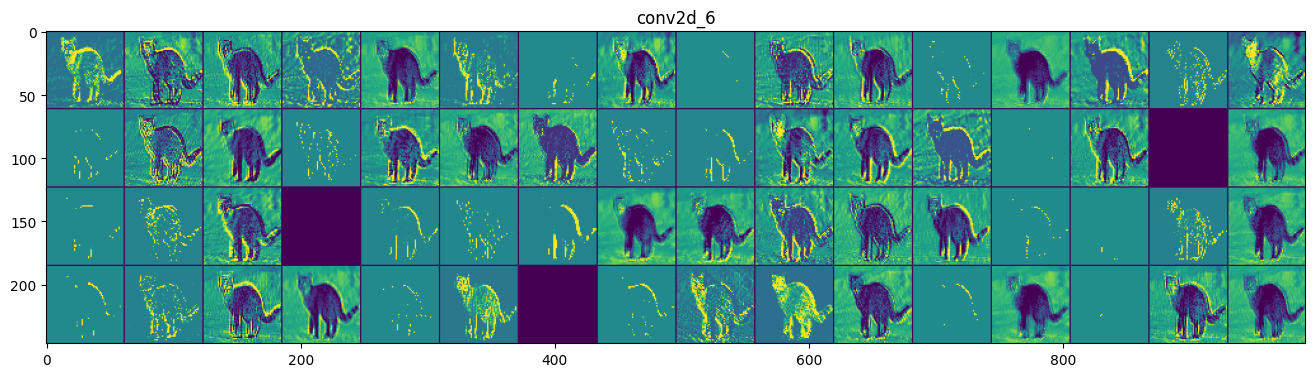

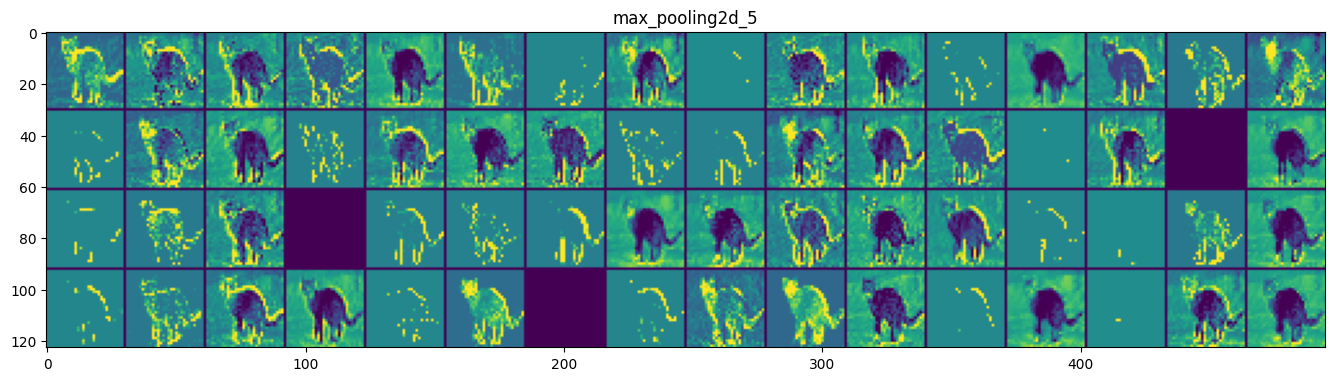

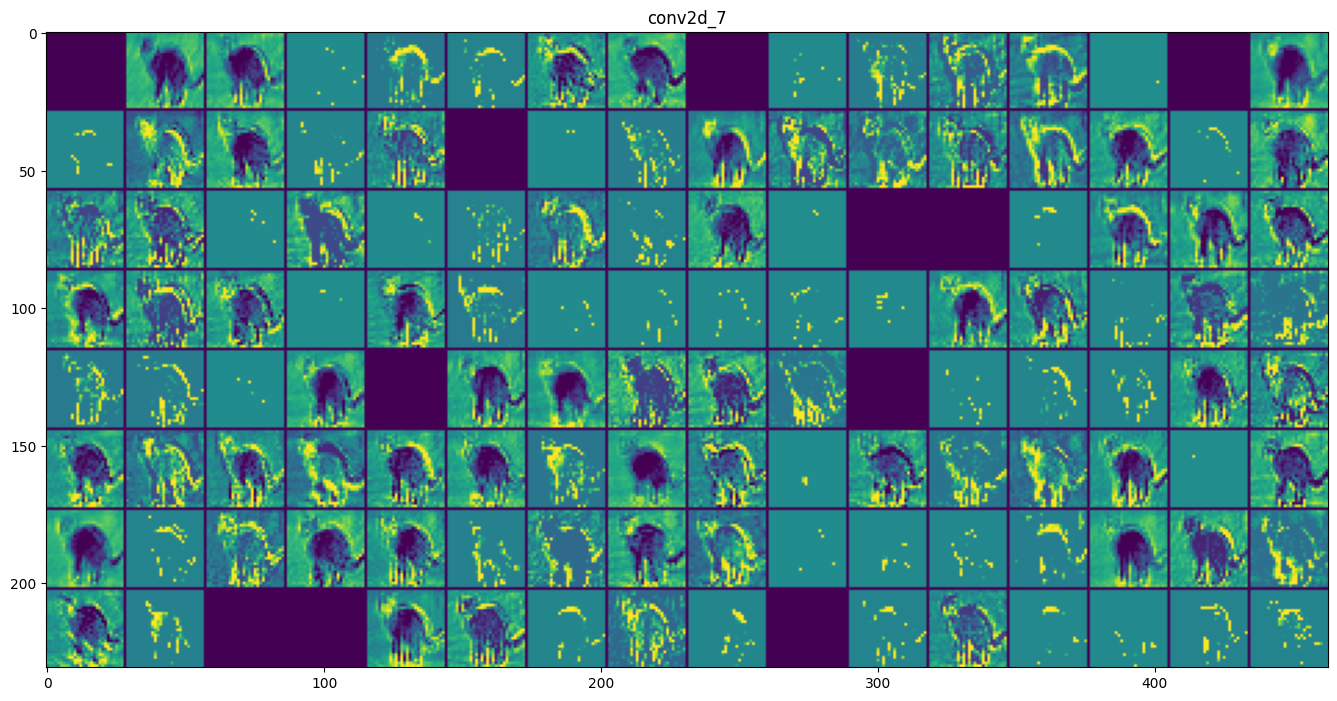

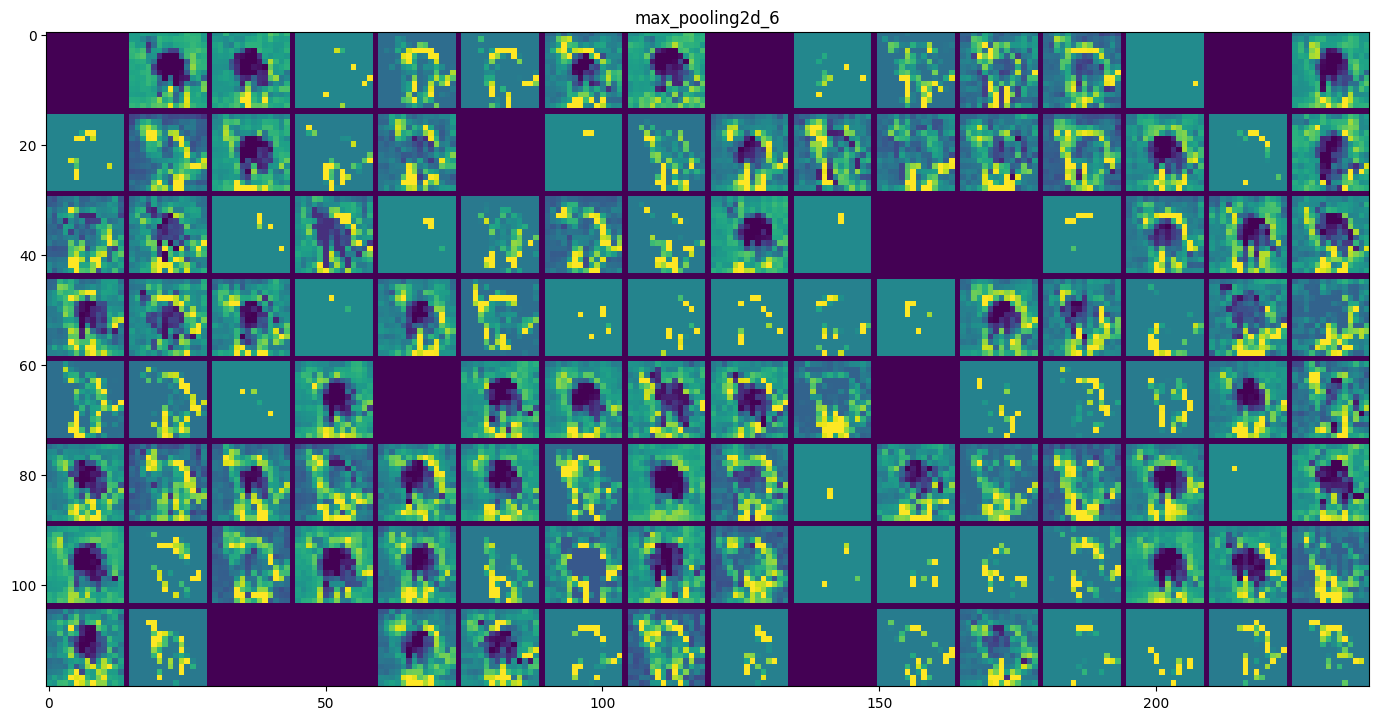

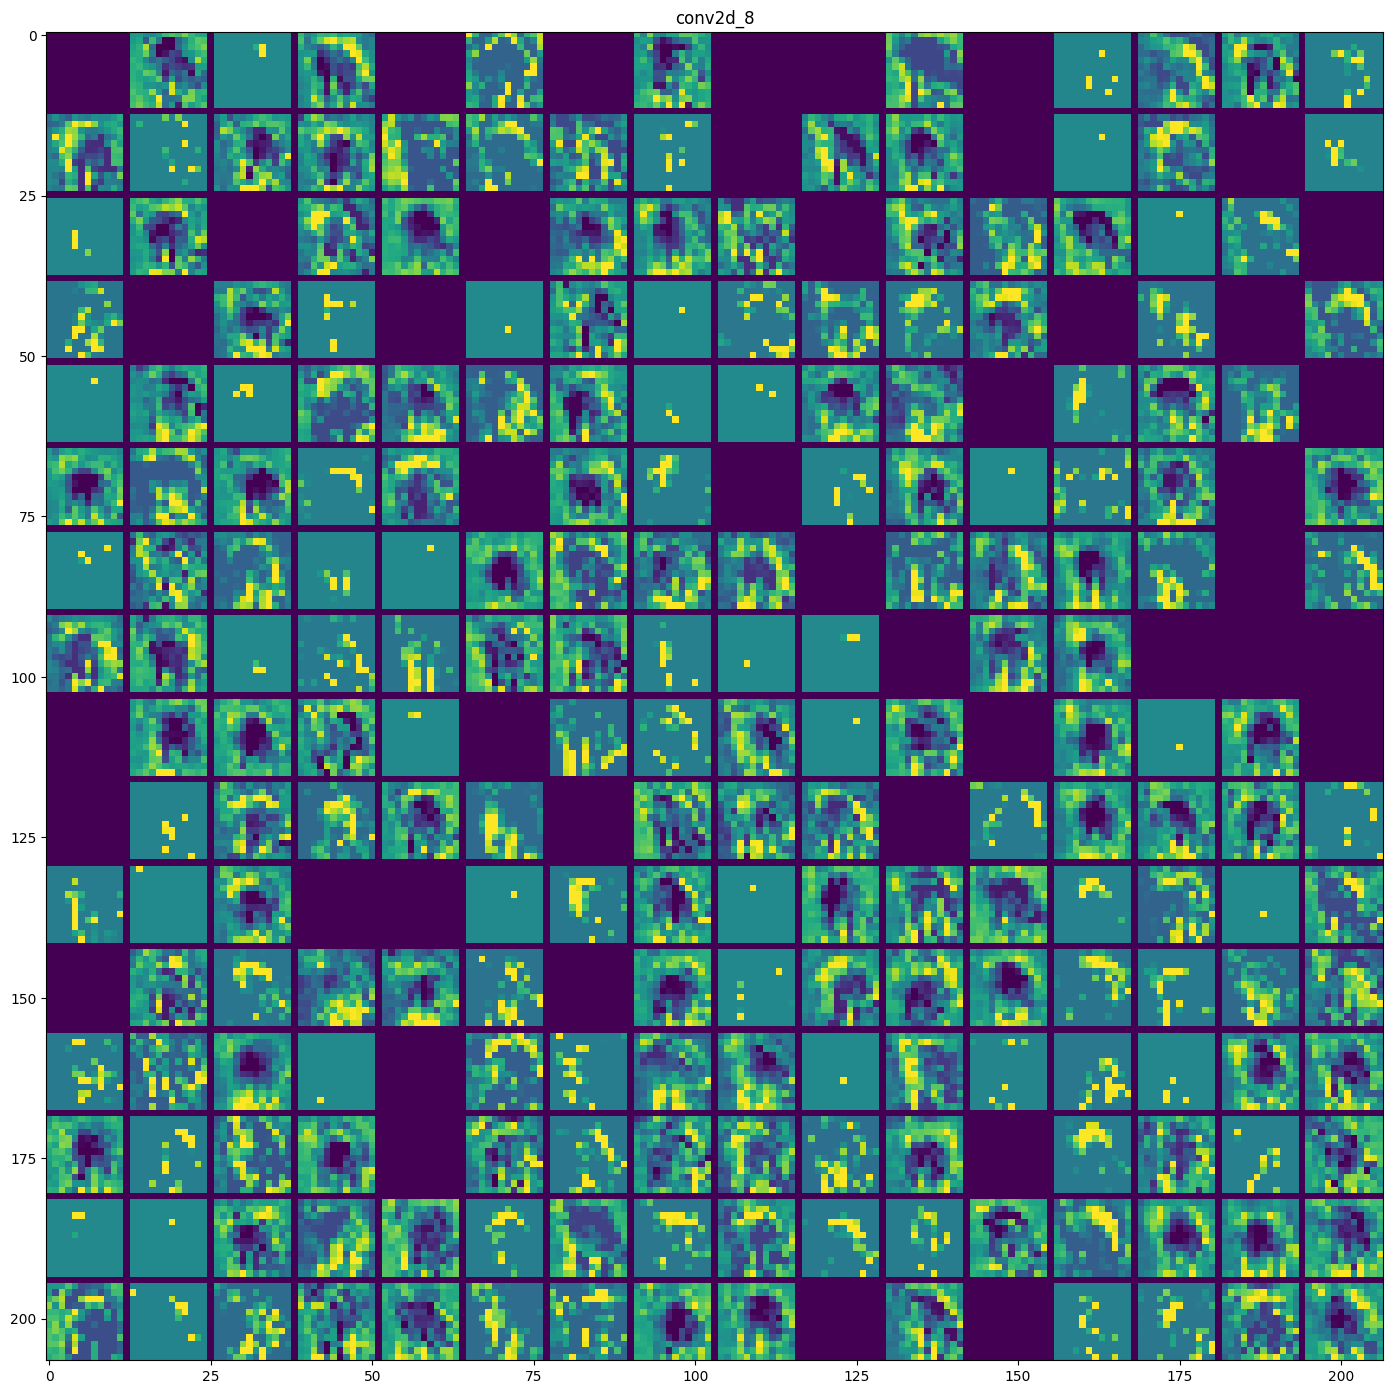

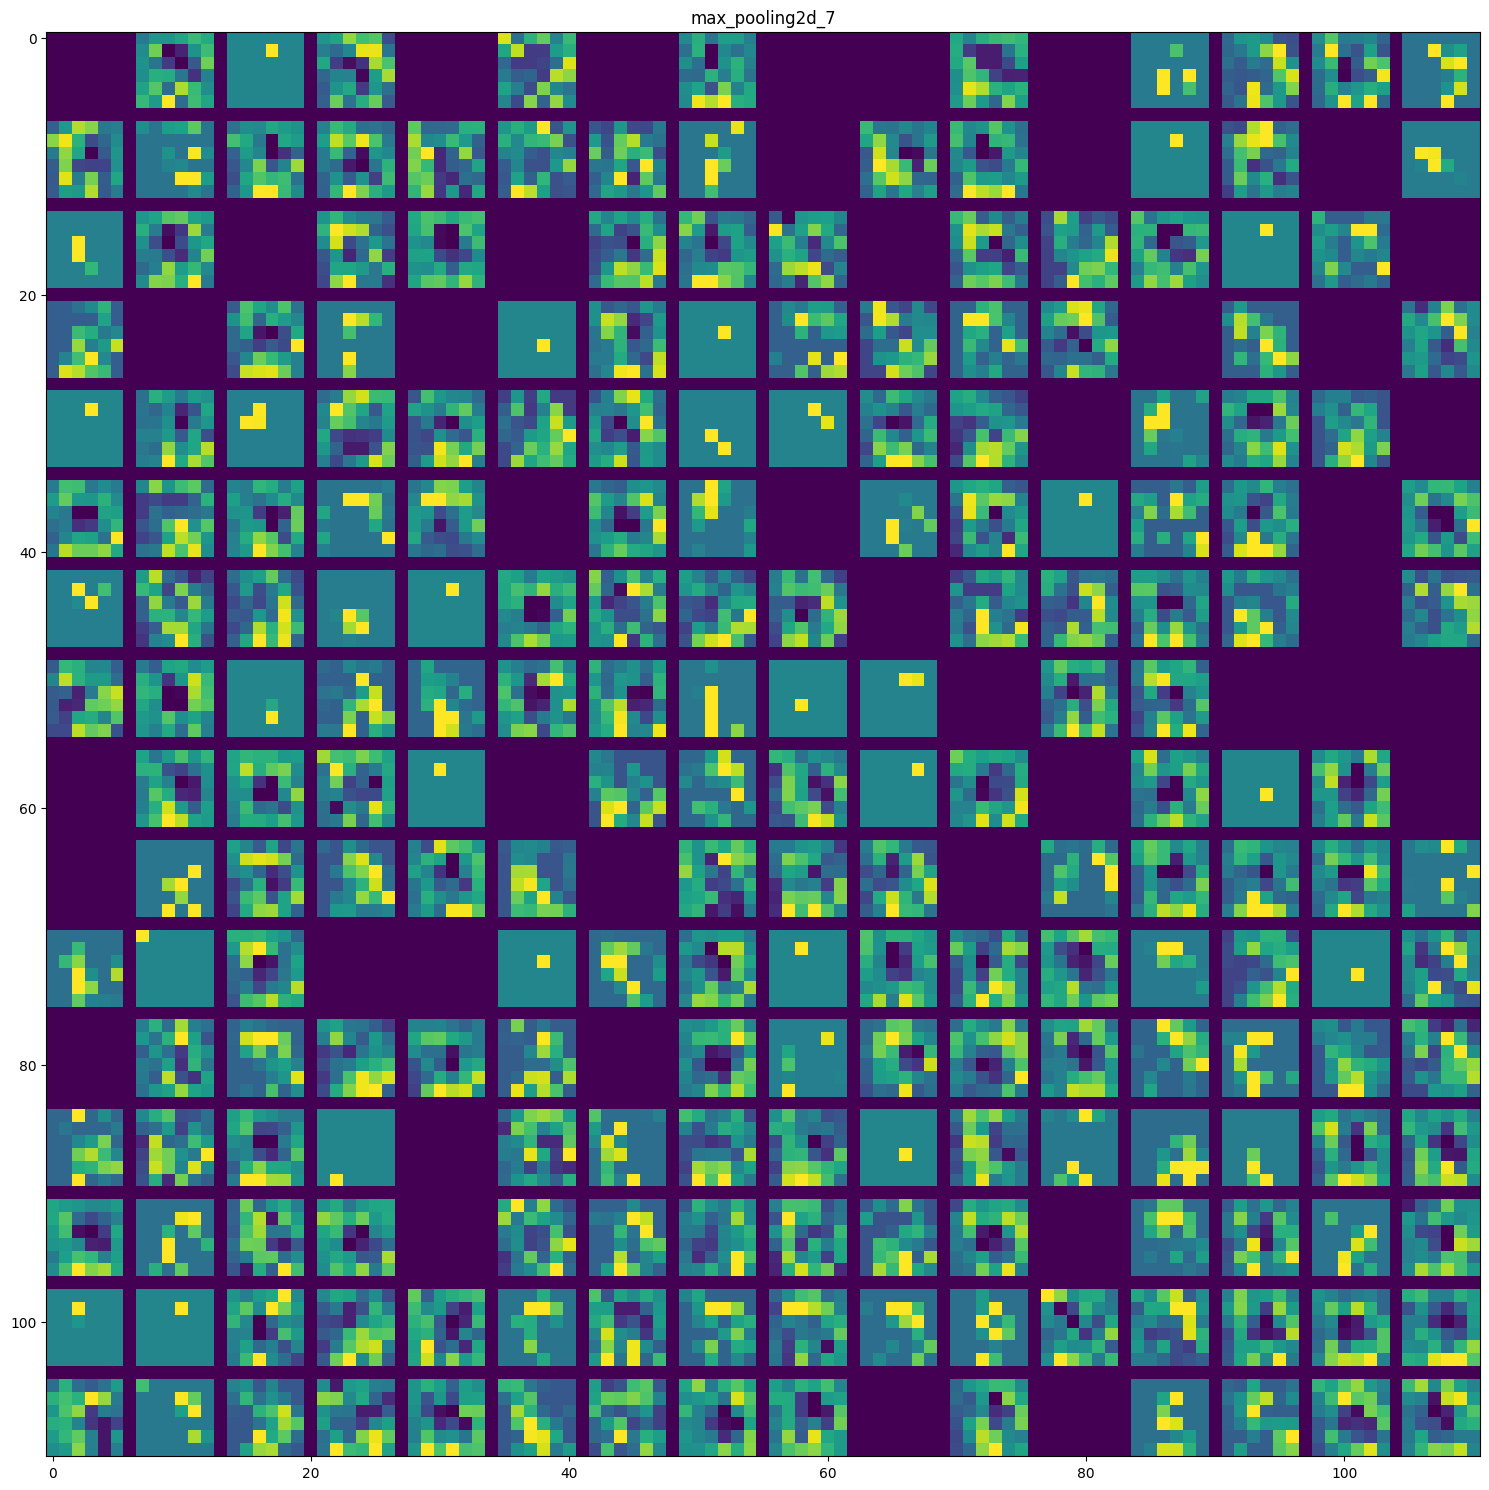

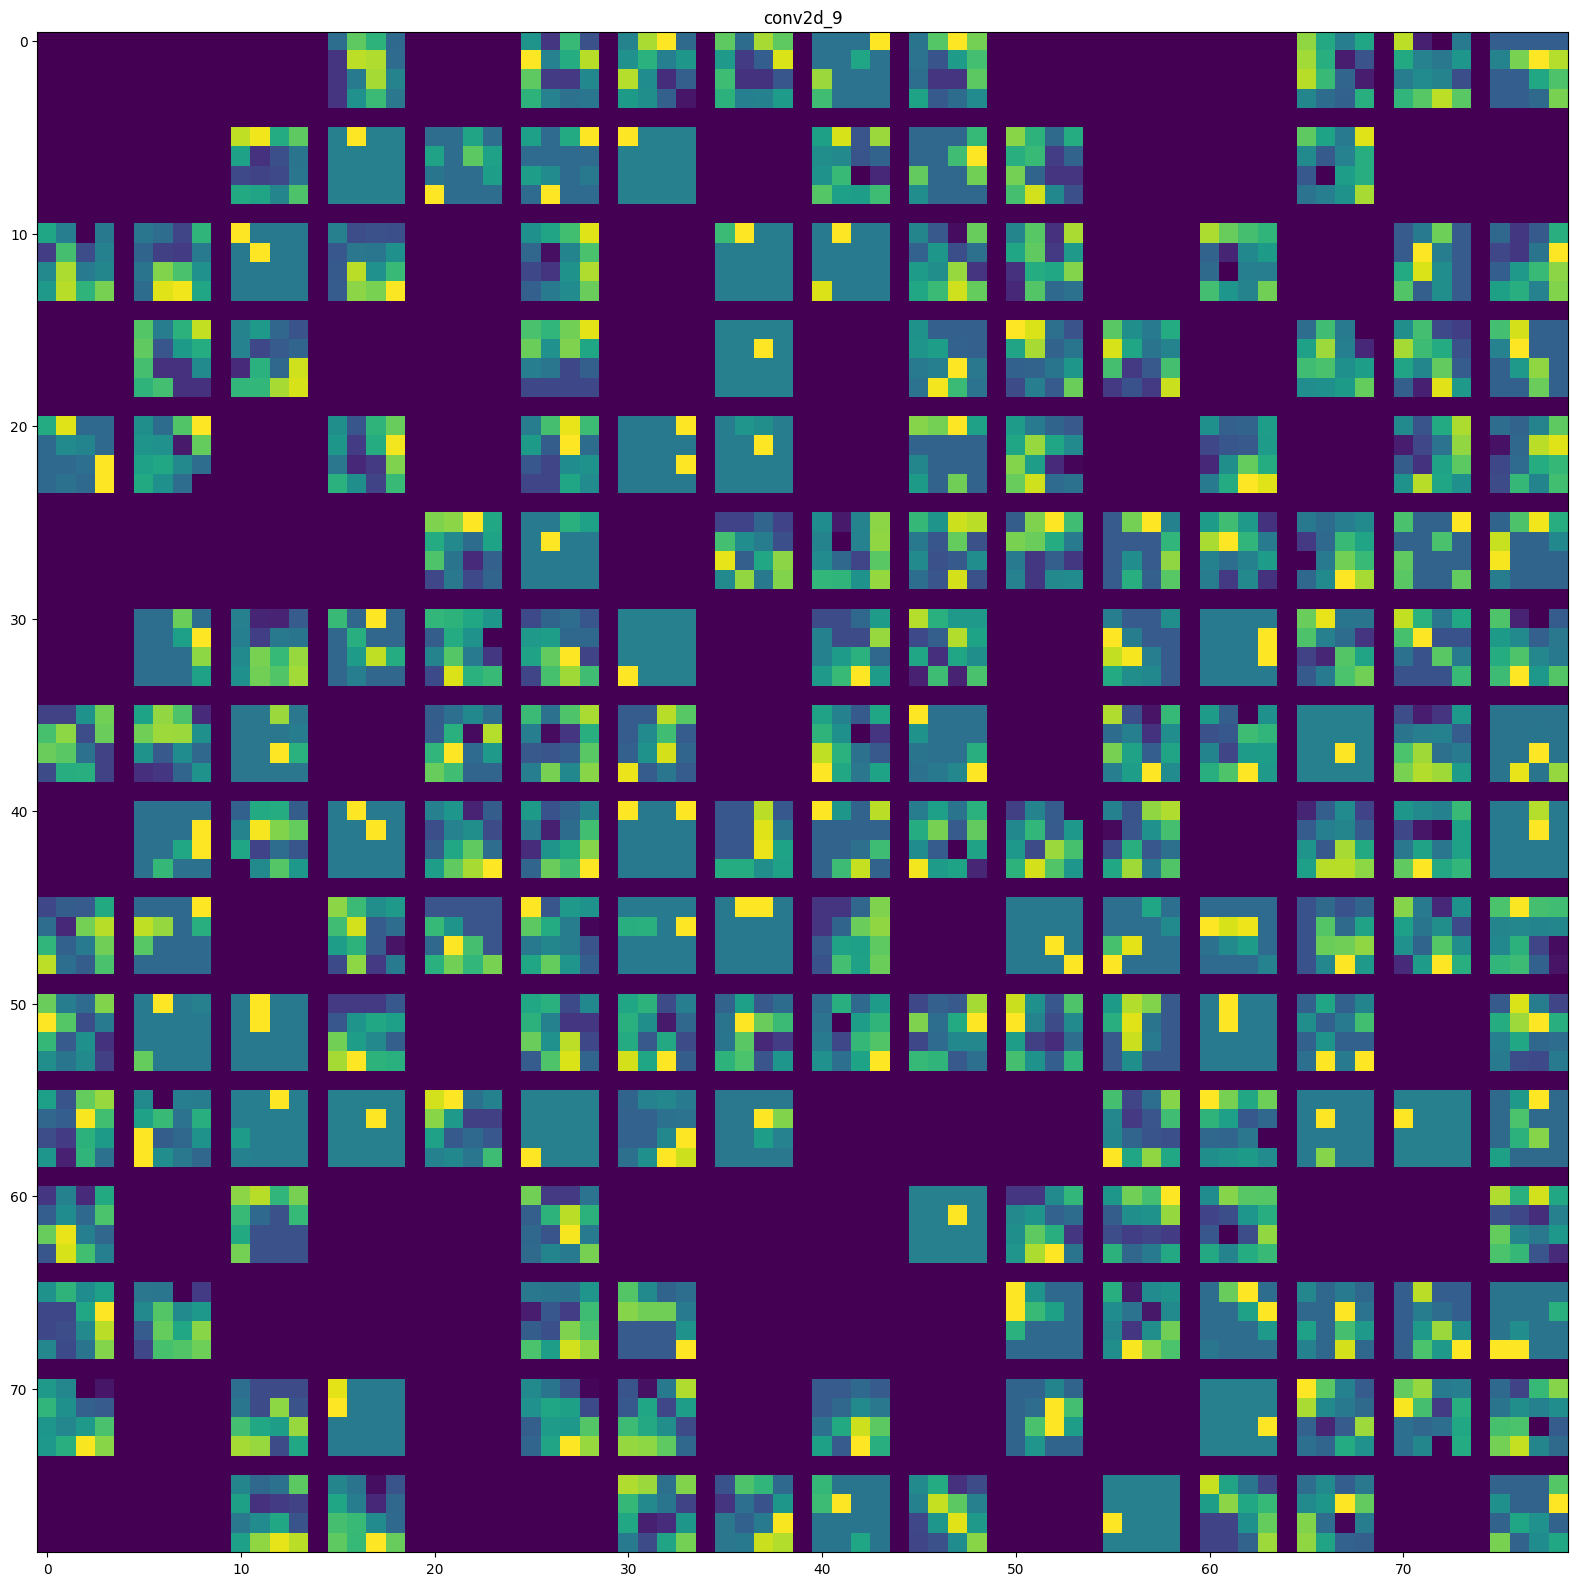

In [26]:
images_per_row = 16

for layer_name, layer_activation in zip(layers_name, activation):

    n_features = layer_activation.shape[-1]
    size = layer_activation.shape[1]

    n_cols = n_features // images_per_row

    display_grid = np.zeros(
        ((size+1)*n_cols -1,
         (size+1)*images_per_row -1)
    )

    for col in range(n_cols):

        for row in range(images_per_row):

            channel_index = col*images_per_row + row

            channel_image = layer_activation[
                0, :, :, channel_index
            ].copy()

            # Normalize EACH channel
            if channel_image.sum() != 0:

                channel_image -= channel_image.mean()

                std = channel_image.std()

                if std != 0:
                    channel_image /= std

                channel_image *= 64
                channel_image += 128

            channel_image = np.clip(
                channel_image,0,255
            ).astype("uint8")

            # Put image into grid
            display_grid[
                col*(size+1):(col+1)*size+col,
                row*(size+1):(row+1)*size+row
            ] = channel_image

    scale = 1./size

    plt.figure(
        figsize=(
            scale*display_grid.shape[1],
            scale*display_grid.shape[0]
        )
    )

    plt.title(layer_name)
    plt.grid(False)

    plt.imshow(
        display_grid,
        aspect="auto",
        cmap="viridis"
    )

    plt.show()